# PE7023 - Project


Diego de Miranda Gomes

Emuobosa Patience Ojoboh


In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


Reservoir engineers assure you that the inflow can be modeled with the single-phase steady-state solution of the Darcy equation for a vertical fully penetrating well:

![Equation 1](eq1.png)


Plot the productivity index PI as a function of rwf.  Comment on your results.

In [14]:
## Reservoir properties
reservoir_pressure = 3800 # Pressure in psi
reservoir_temperature = 200 # Temperature in °F
k = 40 # Permeability in mD
h = 150 # Thickness in ft
re = 372 # Drainage radius in ft
S = 0 # Skin factor
API = 45 # API gravity
muo = 0.902 # Viscosity in cp
gas_specific_gravity = 0.6636 # Gas specific gravity
GOR = 800 # Gas-oil ratio in scf/STB
Pb = 3800 # Bubble point pressure in psi
Bo = 1.2 # Formation volume factor in bbl/STB
max_field_rate = 45000
number_of_wells = 7
max_rate_per_well = max_field_rate / number_of_wells

In [15]:
#Load casing data
wellbore_casing = pd.read_csv('datasets/api_casing_table_full_clean.csv')
## Collumn 'Size (in)' has values like '4 1/2', we need to convert them to decimal
wellbore_casing['Size (in) decimal'] = wellbore_casing['Size (in)'].apply(lambda x: eval(x.replace(' ', '+')))
wellbore_casing_external_diameter = wellbore_casing[['Size (in)', 'Size (in) decimal']].copy()
wellbore_casing_external_diameter.drop_duplicates(inplace=True)
max_diameter = 8.5
wellbore_casing_external_diameter = wellbore_casing_external_diameter[wellbore_casing_external_diameter['Size (in) decimal'] <= max_diameter]


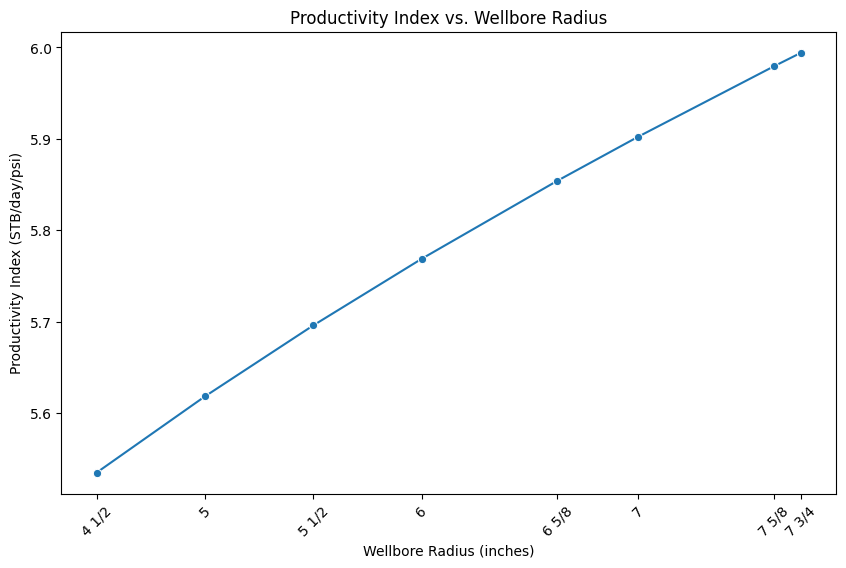

In [16]:
def PI(k, h, Bo, muo, re, rwf, S):
    # Calculate the productivity index (PI) using the given parameters
    # k: permeability (mD)
    # h: thickness of the reservoir (ft)
    # Bo: formation volume factor (bbl/STB)
    # muo: viscosity of oil (cp)
    # re: drainage radius (ft)
    # rwf: wellbore radius (ft)
    # S: skin factor

    # Convert permeability from mD to ft^2
    

    # Calculate the productivity index using the formula:
    # PI = (k * h) / (Bo * muo * (ln(re/rwf) + S))
    PI_value = (k * h) / (141.2 * Bo * muo * (np.log(re / rwf) -0.5 + S))

    return PI_value


## Evaluate different wellbore radii
wellbore_case_inches = wellbore_casing_external_diameter['Size (in) decimal'].values # Wellbore case sizes in inches
wellbore_radii = [case / 2 / 12 for case in wellbore_case_inches] # Convert to feet
PI_values = [PI(k, h, Bo, muo, re, rwf, S) for rwf in wellbore_radii]
# Plotting the results
plt.figure(figsize=(10, 6))
## Use the original 'Size (in)' for the x-axis labels but scale it using the decimal values for the x-axis positions
sns.lineplot(x=wellbore_casing_external_diameter['Size (in) decimal'], y=PI_values, marker='o')
plt.xticks(ticks=wellbore_casing_external_diameter['Size (in) decimal'], labels=wellbore_casing_external_diameter['Size (in)'])
## make x-axis labels inclined
plt.xticks(rotation=45)
plt.title('Productivity Index vs. Wellbore Radius')
plt.xlabel('Wellbore Radius (inches)')
plt.ylabel('Productivity Index (STB/day/psi)')
plt.show()



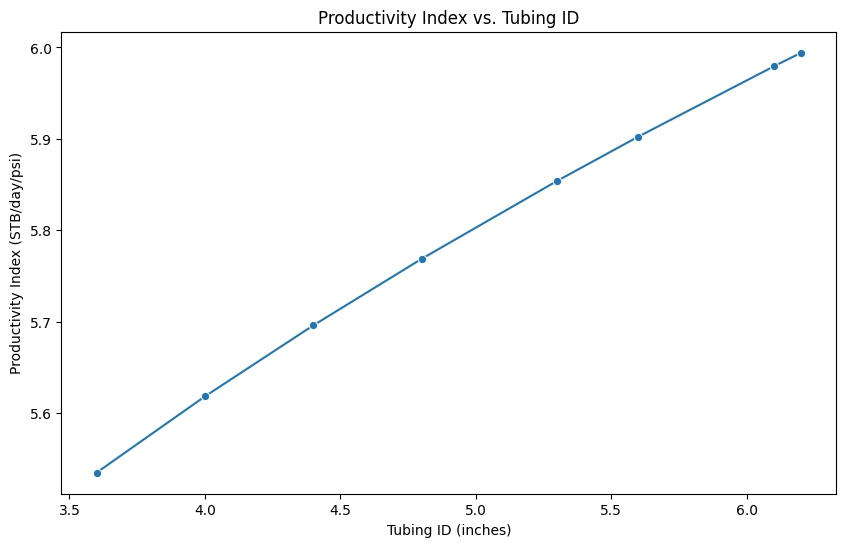

In [17]:
tubing_id = [0.8 * case for case in wellbore_case_inches] # Assuming tubing ID is 80% of the wellbore radius
## Plotiing tubing ID vs. PI
plt.figure(figsize=(10, 6))
sns.lineplot(x=tubing_id, y=PI_values, marker='o')
plt.title('Productivity Index vs. Tubing ID')
plt.xlabel('Tubing ID (inches)')
plt.ylabel('Productivity Index (STB/day/psi)')
plt.show()


In [18]:
#Show Tubing ID vs. PI in a table
data = {'Tubing ID (inches)': tubing_id, 'Productivity Index (STB/day/psi)': PI_values}
df = pd.DataFrame(data)
## Show numbers with 1 decimal place
df['Productivity Index (STB/day/psi)'] = df['Productivity Index (STB/day/psi)'].round(1)
df['PI Improvement (%)'] = df['Productivity Index (STB/day/psi)']/df['Productivity Index (STB/day/psi)'].iloc[0] * 100
df['PI Improvement (%)'] = df['PI Improvement (%)'].round(1)

print(df)


   Tubing ID (inches)  Productivity Index (STB/day/psi)  PI Improvement (%)
0                 3.6                               5.5               100.0
1                 4.0                               5.6               101.8
2                 4.4                               5.7               103.6
3                 4.8                               5.8               105.5
4                 5.3                               5.9               107.3
5                 5.6                               5.9               107.3
6                 6.1                               6.0               109.1
7                 6.2                               6.0               109.1


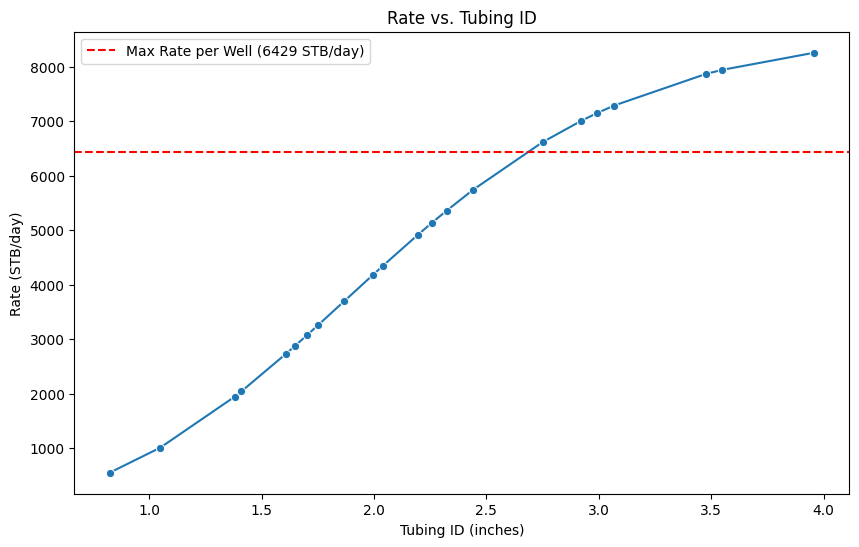

In [19]:
id_x_rate = pd.read_csv('datasets/id_x_rate.csv')
id_x_rate.columns = ['Tubing ID (inches)', 'Rate (STB/day)']
## Plotting Tubing ID vs. Rate
plt.figure(figsize=(10, 6))
sns.lineplot(x=id_x_rate['Tubing ID (inches)'], y=id_x_rate['Rate (STB/day)'], marker='o')
## Draw a horizontal line at the maximum rate per well
plt.axhline(y=max_rate_per_well, color='r', linestyle='--', label=f'Max Rate per Well ({max_rate_per_well:.0f} STB/day)')
plt.legend()
plt.title('Rate vs. Tubing ID')
plt.xlabel('Tubing ID (inches)')
plt.ylabel('Rate (STB/day)')
plt.show()


The minimum diamater to produce the max rate is 2.750, corresponding to an OD of 3.5. So the casing should have an ID minimum of 5.5. So the minimum OD is 6 5/8

In [20]:
id_x_rate

,Tubing ID (inches),Rate (STB/day)
0,0.824,546.812
1,1.049,1006.500
2,1.380,1942.246
3,1.410,2040.273
4,1.610,2735.863
5,1.650,2881.505
6,1.703,3076.656
7,1.751,3256.602
8,1.867,3695.009
9,1.995,4179.119
